In [17]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D

/tmp/ipykernel_32376/2254799244.py:91: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, pad=0.02)


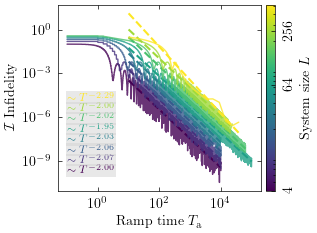

In [42]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from pathlib import Path
import numpy as np

# -----------------------------
# Load data
# -----------------------------
data_dir = Path("../data/adiabatic")
npz_files = sorted(data_dir.glob("adiabatic_L*_dt*_filling*.npz"))

if not npz_files:
    raise RuntimeError("No .npz files found in data/adiabatic")

L_values = sorted({int(f.stem.split("_")[1][1:]) for f in npz_files})
DT_values = sorted({float(f.stem.split("_")[2][2:].replace("p", ".")) for f in npz_files})
dt_to_plot_s = [0.1, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0]

color_map = cm.get_cmap("viridis")
norm = LogNorm(vmin=min(L_values), vmax=max(L_values))

lower_cuts = [200, 600, 600, 700, 700, 700, 700, 150]


# -----------------------------
# Plot curves and collect alpha values
# -----------------------------
alphas = []
colors = []

x_min = 0.1
y_min = 1e-10
y_max_for_labels = 1e-5  # bottom-left region height for labels

for i, L in enumerate(L_values):
    dt_to_plot = dt_to_plot_s[i]
    matching_files = [f for f in npz_files if f"_L{L}_" in f.stem and f"_dt{str(dt_to_plot).replace('.', 'p')}" in f.stem]
    if not matching_files:
        continue
    file = matching_files[0]
    data = np.load(file)
    x = np.array(data["ramp_times"])
    y = np.array(1 - data["fidelities"])

    # log-log fit
    X = np.log(x)[lower_cuts[i]:]
    Y = np.log(y)[lower_cuts[i]:]
    b, alpha = np.linalg.lstsq(np.vstack([np.ones_like(X), X]).T, Y, rcond=None)[0]
    prefactor = np.exp(b)

    x_fit = np.logspace(np.log10(10), np.log10(x.max()), 200)
    y_fit = prefactor * x_fit**alpha

    color = color_map(norm(L))
    plt.plot(x, y, color=color, alpha=0.8, lw=1)
    plt.plot(x_fit, y_fit, color=color, lw=1.5, ls='--')

    alphas.append(alpha)
    colors.append(color)

# -----------------------------
# Place alpha labels intelligently in log space
# -----------------------------
n_labels = len(alphas)
log_y_min = np.log10(y_min)
log_y_max = np.log10(y_max_for_labels)

# -----------------------------
# Place alpha labels intelligently in log space with gray background
# -----------------------------
n_labels = len(alphas)
log_y_positions = np.linspace(log_y_min, log_y_max, n_labels)
for i, alpha in enumerate(alphas):
    plt.text(
        x_min, 
        10**log_y_positions[i], 
        rf"$\sim T^{{{alpha:.2f}}}$", 
        color=colors[i],
        fontsize=8, 
        va='bottom', 
        ha='left',
        bbox=dict(facecolor='lightgray', alpha=0.5, edgecolor='none', pad=1)
    )

# -----------------------------
# Colorbar
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, pad=0.02)
cbar.set_label("System size $L$", fontsize=10)
cbar.set_ticks([4, 64, 256])
cbar.ax.set_yticklabels([str(L) for L in [4, 64, 256]], rotation=90, va='center')

# -----------------------------
# Axis
# -----------------------------
fname = npz_files[0].stem
filling = float(fname.split("_")[3][7:].replace("p","."))
plt.xlabel(r"Ramp time $T_{\mathrm{a}}$", fontsize=10)
plt.ylabel(r"$\mathcal I$ Infidelity", fontsize=10)
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.savefig("figures/adiabatic_powerlaw_fit.pdf", bbox_inches="tight", dpi=300)
plt.show()

/tmp/ipykernel_32376/2930250142.py:91: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, pad=0.02)


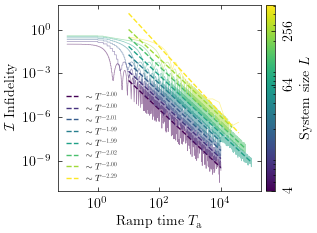

In [66]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from pathlib import Path
import numpy as np

# -----------------------------
# Load data
# -----------------------------
data_dir = Path("../data/adiabatic")
npz_files = sorted(data_dir.glob("adiabatic_L*_dt*_filling*.npz"))

if not npz_files:
    raise RuntimeError("No .npz files found in data/adiabatic")

L_values = sorted({int(f.stem.split("_")[1][1:]) for f in npz_files})
DT_values = sorted({float(f.stem.split("_")[2][2:].replace("p", ".")) for f in npz_files})
dt_to_plot_s = [0.1, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0]

color_map = cm.get_cmap("viridis")
norm = LogNorm(vmin=min(L_values), vmax=max(L_values))

lower_cuts = [200, 1000, 1000, 1000, 1000, 700, 700, 150]

# -----------------------------
# Plot curves and collect alpha values
# -----------------------------
alphas = []
colors = []

raw_x_s = []
raw_y_s = []


for i, L in enumerate(L_values):
    dt_to_plot = dt_to_plot_s[i]
    matching_files = [f for f in npz_files if f"_L{L}_" in f.stem and f"_dt{str(dt_to_plot).replace('.', 'p')}" in f.stem]
    if not matching_files:
        continue
    file = matching_files[0]
    data = np.load(file)
    x = np.array(data["ramp_times"])
    y = np.array(1 - data["fidelities"])
    raw_x_s.append(x)
    raw_y_s.append(y)

    # log-log fit
    X = np.log(x)[lower_cuts[i]:]
    Y = np.log(y)[lower_cuts[i]:]
    b, alpha = np.linalg.lstsq(np.vstack([np.ones_like(X), X]).T, Y, rcond=None)[0]
    prefactor = np.exp(b)

    x_fit = np.logspace(np.log10(10), np.log10(x.max()), 200)
    y_fit = prefactor * x_fit**alpha

    color = color_map(norm(L))
    plt.plot(x, y, color=color, alpha=0.5, lw=0.5)
    plt.plot(x_fit, y_fit, color=color, lw=1, ls='--')

    alphas.append(alpha)
    colors.append(color)

# -----------------------------
# Create a legend with alpha values instead of individual labels
# -----------------------------
legend_elements = [Line2D([0], [0], color=color, lw=1, ls='--', label=rf"$\sim T^{{{alpha:.2f}}}$") 
                   for color, alpha in zip(colors, alphas)]

legend = plt.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=6.5,
    frameon=True,              # draw frame
    framealpha=0,            # make it slightly transparent
    facecolor='white',     # background color
    edgecolor='none'           # optional: no border
)
from matplotlib import patheffects as PathEffects
# add white outline to each legend text
for text in legend.get_texts():
    text.set_path_effects([
        PathEffects.withStroke(linewidth=0.5, foreground='white')
    ])

# -----------------------------
# Colorbar
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, pad=0.02)
cbar.set_label("System size $L$", fontsize=10)
cbar.set_ticks([4, 64, 256])
cbar.ax.set_yticklabels([str(L) for L in [4, 64, 256]], rotation=90, va='center')

# -----------------------------
# Axis
# -----------------------------
fname = npz_files[0].stem
filling = float(fname.split("_")[3][7:].replace("p","."))
plt.xlabel(r"Ramp time $T_{\mathrm{a}}$", fontsize=10)
plt.ylabel(r"$\mathcal I$ Infidelity", fontsize=10)
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.savefig("figures/adiabatic_powerlaw_fit.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [2]:
import numpy as np
from scipy.linalg import eigh, expm, det
import time
from scipy.sparse.linalg import expm_multiply
from matplotlib import pyplot as plt
import tqdm

In [3]:
def xx_ham(L, J=1.0, boundary_coupling=1.0):
    A = np.zeros((L, L), dtype=complex)

    for i in range(L - 1):
        A[i, i+1] = J
        A[i+1, i] = J

    mid = L//2 - 1
    A[mid, mid+1] *= boundary_coupling
    A[mid+1, mid] *= boundary_coupling

    return A

def ground_state(A, Nf):
    # Slater determinant ground state of Nf filled lowest levels
    eps, V = eigh(A)
    idx = np.argsort(eps)
    V = V[:, idx]
    Phi = V[:, :Nf]
    return Phi, eps[idx]

def slater_fidelity(Phi1, Phi2):
    overlap = np.linalg.det(Phi1.conj().T @ Phi2)
    return np.abs(overlap)**2

def adiabatic_fusion(L, Nf, dt = 0.1, T=5.0):
    steps = int(T / dt)

    A0 = xx_ham(L, boundary_coupling=0.0)
    Phi, _ = ground_state(A0, Nf)

    for s in range(steps):
        lam = (s + 1) / steps
        A = xx_ham(L, boundary_coupling=lam)

        Phi = expm_multiply(-1j * A * dt, Phi)

        U, _, Vh = np.linalg.svd(Phi, full_matrices=False)
        Phi = U @ Vh

    return Phi

def superiteration(T_total, alpha, dt=1e-6):
    first_term = T_total * (1-1/alpha)
    times = []
    while first_term > dt:
        times.append(first_term)
        first_term /= alpha

    times.append(first_term)
    times_rounded = [(t+1e-7)//dt * dt for t in times]
    return times_rounded

In [4]:
I0_s = []
for L in L_values:
    filling = 0.5

    Nf = int(L * filling)

    #dt_values = [0.1, 0.05, 0.01]
    #ramp_times = np.linspace(1.0, 100.0, 500)
    dt_values = [1]#[0.5, 0.25]#, 0.1, 0.05]
    ramp_times = [0]#np.logspace(1, 4, 100)
    A_full = xx_ham(L, boundary_coupling=1.0)
    Phi_target, eps = ground_state(A_full, Nf)
    A0_unfused = xx_ham(L, boundary_coupling=0.0)
    Phi, _ = ground_state(A0_unfused, Nf)
    E0 = np.sum(eps[:Nf])
    print("Initial overlap," , slater_fidelity(Phi, Phi_target))

    all_fidelities = []
    for dt in dt_values:
        fidelities_single_dt = []
        for ramp_time in tqdm.tqdm(ramp_times):
            Phi = adiabatic_fusion(L, Nf, dt=dt, T=ramp_time)

            fid = slater_fidelity(Phi, Phi_target)
            fidelities_single_dt.append(fid)
        all_fidelities.append(np.array(fidelities_single_dt))
    I0_s.append(1-slater_fidelity(Phi, Phi_target))

Initial overlap, 0.8972135954999585


100%|██████████| 1/1 [00:00<00:00, 3942.02it/s]


Initial overlap, 0.8415194457655111


100%|██████████| 1/1 [00:00<00:00, 6345.39it/s]


Initial overlap, 0.7828712176562386


...

100%|██████████| 1/1 [00:00<00:00, 330.73it/s]


Initial overlap, 0.5655275670300112


100%|██████████| 1/1 [00:00<00:00, 28.77it/s]


Initial overlap, 0.519255928332277


100%|██████████| 1/1 [00:00<00:00,  4.29it/s]


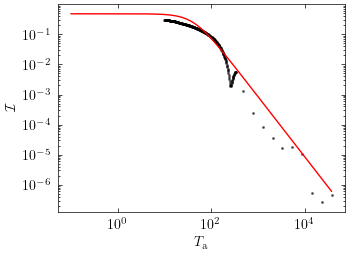

In [76]:
long_masks = [10, 10, 30, 100, 100, 1000, 500, 100]
for Li, L in enumerate(L_values):
    if L != 512:
        continue
    T = raw_x_s[Li]
    I = raw_y_s[Li]
    I0 = I0_s[Li] # Known zero-time infidelity

    # Fit late-time coefficient A using long-time peaks
    from scipy.signal import find_peaks

    upper_cutoff = np.percentile(I*T**2, 75)  # find peaks in I*T^2 to get envelope
    peaks = np.where(I*T**2 >= upper_cutoff)[0]
    T_peaks = T[peaks]
    I_peaks = I[peaks]

    # Take late-time peaks, e.g. last 10% of data
    long_mask = T_peaks >= long_masks[Li]
    T_long = T_peaks[long_mask]
    I_long = I_peaks[long_mask]

    # Fit A exactly from T^-2 envelope
    A = np.mean(I_long * T_long**2)

    # Smooth interpolation function
    def I_func(Tval):
        return I0 / (1 + (I0/A)*Tval**2)

    # Inverse function T(I) analytically
    def T_A(I_target):
        I_target = np.minimum(I_target, I0)  # cannot exceed I0
        return np.sqrt(A * (I0/I_target - 1))

    # Plot
    T_plot = np.logspace(np.log10(0.1), np.log10(T.max()), 500)
    plt.scatter(T, I,  marker='.', alpha=0.5, color="black", s=5)
    plt.loglog(T_plot, I_func(T_plot), '-', color='red')
    #plt.loglog(T_long, I_long, 'x', label='Late-time peaks')
plt.xlabel(r"$T_{\mathrm{a}}$")
plt.ylabel(r"$\mathcal I$")
#plt.title(r"Adiabatic Fusion: $L=8$, $\Delta t = 0.5$, $\nu = 0.5$")
#plt.savefig("figures/adiabatic_fit_L8.pdf", bbox_inches="tight")
plt.show()

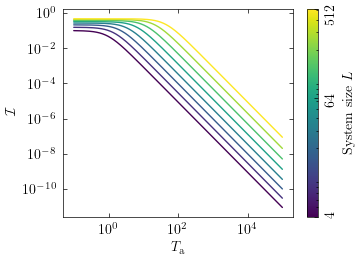

I0 values: [0.1027864045000415, 0.15848055423448892, 0.21712878234376143, 0.2753152188716519, 0.33144440632900085, 0.38465012849689273, 0.43447243296998883, 0.48074407166772304]
A values: [0.08684806210189, 0.2937239784883905, 0.9834885193110438, 3.462006409300839, 12.945996946981577, 50.10131717876259, 200.2807615148392, 865.7989782959032]


In [77]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import numpy as np

# Example L_values (log-spaced)
# L_values = np.array([4, 8, 16, 32, 64, 128, 256, 512])
colors = cm.viridis  # continuous colormap

fig, ax = plt.subplots()

# Prepare normalization for logarithmic L values
norm = LogNorm(vmin=min(L_values), vmax=max(L_values))

A_values = []
long_masks = [10, 10, 30, 100, 100, 1000, 500, 100]

for Li, L in enumerate(L_values):
    T = raw_x_s[Li]
    I = raw_y_s[Li]
    I0 = I0_s[Li]  # Known zero-time infidelity

    # Fit late-time coefficient A using long-time peaks
    from scipy.signal import find_peaks

    upper_cutoff = np.percentile(I*T**2, 75)  # find peaks in I*T^2 to get envelope
    peaks = np.where(I*T**2 >= upper_cutoff)[0]
    T_peaks = T[peaks]
    I_peaks = I[peaks]

    # Take late-time peaks, e.g. last 10% of data
    long_mask = T_peaks >= long_masks[Li]
    T_long = T_peaks[long_mask]
    I_long = I_peaks[long_mask]

    # Fit A exactly from T^-2 envelope
    A = np.mean(I_long * T_long**2)
    A_values.append(A)

    # Smooth interpolation function
    def I_func(Tval):
        return I0 / (1 + (I0/A)*Tval**2)

    # Plot using colormap
    T_plot = np.logspace(np.log10(0.1), np.log10(1e5), 500)
    ax.loglog(T_plot, I_func(T_plot), color=colors(norm(L)))

# Colorbar for L values
sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])  # only needed for colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("System size $L$")
cbar.set_ticks([4, 64, 512])
cbar.set_ticklabels([4, 64, 512])
cbar.ax.tick_params(rotation=90)  # rotate labels

ax.set_xlabel(r"$T_{\mathrm{a}}$")
ax.set_ylabel(r"$\mathcal I$")
plt.savefig("figures/tapered_fit_all.pdf", bbox_inches="tight")
plt.show()
print("I0 values:", I0_s)
print("A values:", A_values)